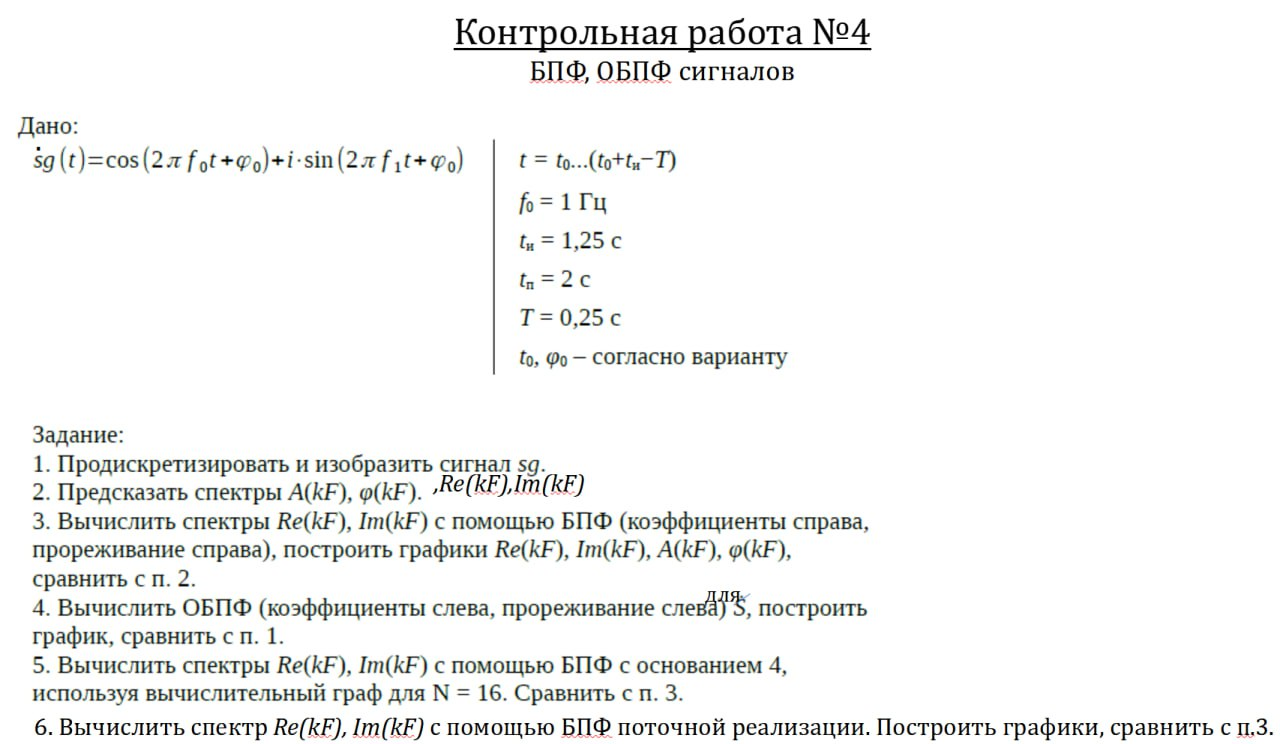

In [45]:
import numpy as np
import sympy
import matplotlib.pyplot as plt

# Служебные переменные
LAST_FIGURE_NUMBER = 0

# Константы
i = complex(0, 1)
pi = np.pi

# Данные по варианту
T = 0.25
t_i = 1.25
t_p = 2
f = 1

t_0 = 0.5
fi_0 = 3 * np.pi/ 4

n_i = t_i / T
n_p = t_p / T
n_0 = t_0 / T

for n in range(-2, 3):
  sg = np.cos(2*pi*f*n*T + fi_0) + 1j * np.sin(2*pi*f*n*T + fi_0)
  print(n, ': ', np.round(sg, 3))

-2 :  (0.707-0.707j)
-1 :  (0.707+0.707j)
0 :  (-0.707+0.707j)
1 :  (-0.707-0.707j)
2 :  (0.707-0.707j)


In [46]:
start_fi = 7*np.pi/4
print('0:')
print('cos:', np.cos(start_fi))
print('sin:', np.sin(start_fi))

print('1:')
print('cos:', np.cos(start_fi - np.pi))
print('sin:', np.sin(start_fi - np.pi))

print('2:')
print('cos:', np.cos(start_fi - np.pi))
print('sin:', np.sin(start_fi - np.pi))

print('3:')
print('cos:', np.cos(start_fi - np.pi))
print('sin:', np.sin(start_fi - np.pi))

print('4:')
print('cos:', np.cos(start_fi - 2*np.pi))
print('sin:', np.sin(start_fi - 2*np.pi))

print('5:')
print('cos:', np.cos(start_fi - 2*np.pi))
print('sin:', np.sin(start_fi - 2*np.pi))

print('6:')
print('cos:', np.cos(start_fi - 3*np.pi))
print('sin:', np.sin(start_fi - 3*np.pi))

print('7:')
print('cos:', np.cos(start_fi - 4*np.pi))
print('sin:', np.sin(start_fi - 4*np.pi))

0:
cos: 0.7071067811865474
sin: -0.7071067811865477
1:
cos: -0.7071067811865475
sin: 0.7071067811865476
2:
cos: -0.7071067811865475
sin: 0.7071067811865476
3:
cos: -0.7071067811865475
sin: 0.7071067811865476
4:
cos: 0.7071067811865476
sin: -0.7071067811865475
5:
cos: 0.7071067811865476
sin: -0.7071067811865475
6:
cos: -0.7071067811865477
sin: 0.7071067811865475
7:
cos: 0.7071067811865477
sin: -0.7071067811865474


### БПФ

In [47]:
sg_list = []

for n in range(8):
  sg = np.cos(2*pi*f*n*T + fi_0) + 1j * np.sin(2*pi*f*n*T + fi_0)
  if n >= 3 and n <= 5:
    sg = 0 + 0j
  sg_list.append(sg)
  print(n, ': ', np.round(sg_list[n], 2))



0 :  (-0.71+0.71j)
1 :  (-0.71-0.71j)
2 :  (0.71-0.71j)
3 :  0j
4 :  0j
5 :  0j
6 :  (0.71-0.71j)
7 :  (0.71+0.71j)


In [48]:
W = np.exp(-1j * np.pi / 4)

stage1 = np.zeros(8, complex)

n = 0
m = 4

for n in range(4):
  stage1[n] = sg_list[n] + sg_list[m]
  stage1[m] = (sg_list[n] - sg_list[m]) * (W ** n)
  # print(f'n = {n}, {np.round(sg_list[n], 2)} + {np.round(sg_list[m], 2)}')
  # print(f'm = {m}, ({np.round(sg_list[n], 2)} - {np.round(sg_list[m], 2)}) * {np.round(W ** n, 2)}')
  m += 1

for n in range(8):
  print(n, ': ', np.round(stage1[n], 2))

0 :  (-0.71+0.71j)
1 :  (-0.71-0.71j)
2 :  (1.41-1.41j)
3 :  (0.71+0.71j)
4 :  (-0.71+0.71j)
5 :  (-1+0j)
6 :  -0j
7 :  (-0+1j)


In [49]:
stage2 = np.zeros(8, complex)

n = 0
m = 2
p = 0

for n in range(0, 2):
  stage2[n] = stage1[n] + stage1[m]
  stage2[m] = (stage1[n] - stage1[m]) * (W ** p)
  # print(f'n = {n}, {np.round(stage1[n], 2)} + {np.round(stage1[m], 2)}')
  # print(f'm = {m}, ({np.round(stage1[n], 2)} - {np.round(stage1[m], 2)}) * {np.round(W ** p, 2)}')
  m += 1
  p += 2

n = 4
m = 6
p = 0

for n in range(4, 6):
  stage2[n] = stage1[n] + stage1[m]
  stage2[m] = (stage1[n] - stage1[m]) * (W ** p)
  # print(f'n = {n}, {np.round(sg_list[n], 2)} + {np.round(sg_list[m], 2)}')
  # print(f'm = {m}, ({np.round(sg_list[n], 2)} - {np.round(sg_list[m], 2)}) * {np.round(W ** p, 2)}')
  m += 1
  p += 2


for n in range(8):
  print(n, ': ', np.round(stage2[n], 2))

0 :  (0.71-0.71j)
1 :  (-0+0j)
2 :  (-2.12+2.12j)
3 :  (-1.41+1.41j)
4 :  (-0.71+0.71j)
5 :  (-1+1j)
6 :  (-0.71+0.71j)
7 :  (-1+1j)


In [50]:
stage3 = np.zeros(8, complex)

n = 0
m = 1

while m < 8:
  stage3[n] = stage2[n] + stage2[m]
  stage3[m] = (stage2[n] - stage2[m]) * (W ** 0)
  # print(f'n = {n}, {np.round(stage2[n], 2)} + {np.round(stage2[m], 2)}')
  # print(f'm = {m}, ({np.round(stage2[n], 2)} - {np.round(stage2[m], 2)}) * {np.round(W ** 0, 2)}')
  m += 2
  n += 2

for n in range(8):
  print(n, ': ', np.round(stage3[n], 2))

0 :  (0.71-0.71j)
1 :  (0.71-0.71j)
2 :  (-3.54+3.54j)
3 :  (-0.71+0.71j)
4 :  (-1.71+1.71j)
5 :  (0.29-0.29j)
6 :  (-1.71+1.71j)
7 :  (0.29-0.29j)


In [51]:
final_sg = []
final_sg.append(stage3[0])
final_sg.append(stage3[4])
final_sg.append(stage3[2])
final_sg.append(stage3[6])
final_sg.append(stage3[1])
final_sg.append(stage3[5])
final_sg.append(stage3[3])
final_sg.append(stage3[7])

for n in range(8):
  print(n, ': ', np.round(final_sg[n], 2))

0 :  (0.71-0.71j)
1 :  (-1.71+1.71j)
2 :  (-3.54+3.54j)
3 :  (-1.71+1.71j)
4 :  (0.71-0.71j)
5 :  (0.29-0.29j)
6 :  (-0.71+0.71j)
7 :  (0.29-0.29j)


In [52]:
for n in range(8):
  print(n, ': ', np.round(abs(final_sg[n]), 2))

0 :  1.0
1 :  2.41
2 :  5.0
3 :  2.41
4 :  1.0
5 :  0.41
6 :  1.0
7 :  0.41


In [53]:
# import cmath

# phase_spectr = []

# for n in range(8):
#   fi = np.imag(final_sg[n]) / np.real(final_sg[n])
#   print(f'{n}: fi = {fi}')
#   phase_spectr.append(np.arctan(fi))
#   # phase_spectr.append(cmath.phase(fi))

# for n in range(8):
#   print(n, ': ', np.round(phase_spectr[n], 2))

0: fi = -1.000000000000003
1: fi = -0.9999999999999996
2: fi = -1.0000000000000004
3: fi = -0.9999999999999994
4: fi = -1.0000000000000029
5: fi = -0.9999999999999973
6: fi = -1.0000000000000044
7: fi = -0.9999999999999966
0 :  -0.79
1 :  -0.79
2 :  -0.79
3 :  -0.79
4 :  -0.79
5 :  -0.79
6 :  -0.79
7 :  -0.79


### ОБПФ

In [54]:
stage2 = np.zeros(8, complex)

n = 0
m = 1

while m < 8:
  stage2[n] = (stage3[n] + stage3[m] * W ** 0)
  stage2[m] = (stage3[n] - stage3[m] * W ** 0)
  # print(f'n = {n}, {np.round(stage3[n], 2)} + {np.round(stage3[m], 2)} * {np.round(W ** 0, 2)}')
  # print(f'm = {m}, {np.round(stage3[n], 2)} - {np.round(stage3[m], 2)} * {np.round(W ** 0, 2)}')
  n += 2
  m += 2

print()

for n in range(8):
  print(n, ': ', np.round(stage2[n], 2))


0 :  (1.41-1.41j)
1 :  (-0+0j)
2 :  (-4.24+4.24j)
3 :  (-2.83+2.83j)
4 :  (-1.41+1.41j)
5 :  (-2+2j)
6 :  (-1.41+1.41j)
7 :  (-2+2j)


In [55]:
stage1 = np.zeros(8, complex)

n = 0
m = 2
p = 0

for n in range(0, 2):
  stage1[n] = stage2[n] + stage2[m] * (W ** (-p))
  stage1[m] = stage2[n] - stage2[m] * (W ** (-p))
  # print(f'n = {n}, {np.round(stage2[n], 2)} + {np.round(stage2[m], 2)} * {np.round(W ** (-p), 2)}')
  # print(f'm = {m}, {np.round(stage2[n], 2)} - {np.round(stage2[m], 2)} * {np.round(W ** (-p), 2)}')
  m += 1
  p += 2

n = 4
m = 6
p = 0

for n in range(4, 6):
  stage1[n] = stage2[n] + stage2[m] * (W ** (-p))
  stage1[m] = stage2[n] - stage2[m] * (W ** (-p))
  # print(f'n = {n}, {np.round(stage2[n], 2)} + {np.round(stage2[m], 2)} * {np.round(W ** (-p), 2)}')
  # print(f'm = {m}, {np.round(stage2[n], 2)} - {np.round(stage2[m], 2)} * {np.round(W ** (-p), 2)}')
  m += 1
  p += 2

print()

for n in range(8):
  print(n, ': ', np.round(stage1[n], 2))


0 :  (-2.83+2.83j)
1 :  (-2.83-2.83j)
2 :  (5.66-5.66j)
3 :  (2.83+2.83j)
4 :  (-2.83+2.83j)
5 :  (-4+0j)
6 :  -0j
7 :  (-0+4j)


In [56]:
orig_sg = np.zeros(8, complex)

n = 0
m = 4

for n in range(4):
  orig_sg[n] = stage1[n] + stage1[m] * (W ** (-n))
  orig_sg[m] = stage1[n] - stage1[m] * (W ** (-n))
  # print(f'n = {n}, {np.round(stage1[n], 2)} + {np.round(stage1[m], 2)} * {np.round(W ** (-n), 2)}')
  # print(f'm = {m}, {np.round(stage1[n], 2)} - {np.round(stage1[m], 2)} * {np.round(W ** (-n), 2)}')
  m += 1

print()

for n in range(8):
  print(n, ': ', np.round(orig_sg[n], 2))

print()

for n in range(8):
  orig_sg[n] = orig_sg[n] / 8
  print(n, ': ', np.round(orig_sg[n], 2))


0 :  (-5.66+5.66j)
1 :  (-5.66-5.66j)
2 :  (5.66-5.66j)
3 :  0j
4 :  -0j
5 :  (-0-0j)
6 :  (5.66-5.66j)
7 :  (5.66+5.66j)

0 :  (-0.71+0.71j)
1 :  (-0.71-0.71j)
2 :  (0.71-0.71j)
3 :  0j
4 :  -0j
5 :  (-0-0j)
6 :  (0.71-0.71j)
7 :  (0.71+0.71j)
